# Colour Metrics over Densities - Evaluation

In [1]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path
from typing import Sequence

import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [2]:
path = "../../"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [3]:
import decode
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)
log = decode.generic.logging.get_logger(__name__)

%config InlineBackend.figure_format='retina'

/data1/shah/miniconda3/envs/decode_uipsf/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/home/shahao/projects/DECODE-Plex/notebook/density/../../decode/__init__.py


In [ ]:
# figure out
path_out = "../../results/density/FigS5-dual_color"
path_out = Path(path_out)

In [ ]:
# some paths and hardware settings
path_scen_base = "../../data/density/FigS5-dual_color/n_frames-1000_n_steps-16_seed-42-3"
path_scen_base = Path(path_scen_base)

path_scen = path_scen_base / "scenarios.pq"
scen = pd.read_parquet(path_scen)

frames = path_scen_base / "frames.pt"
frames = torch.load(frames)

path_gt = path_scen_base / "gt.pt"
gt = torch.load(path_gt)

scen["em"] = gt["em"]
scen["em_ch"] = gt["em_ch"]
scen

n_emitter   density  n_frames          phot_loc  \
snr    index                                                      
medium 0        11.624977  0.030000      1000  [5000.0, 5000.0]   
       1        15.802486  0.040781      1000  [5000.0, 5000.0]   
       2        21.481211  0.055435      1000  [5000.0, 5000.0]   
       3        29.200621  0.075357      1000  [5000.0, 5000.0]   
       4        39.694050  0.102436      1000  [5000.0, 5000.0]   
       5        53.958359  0.139248      1000  [5000.0, 5000.0]   
       6        73.348648  0.189287      1000  [5000.0, 5000.0]   
       7        99.706947  0.257309      1000  [5000.0, 5000.0]   
       8       135.537292  0.349774       737  [5000.0, 5000.0]   
       9       184.243484  0.475468       542  [5000.0, 5000.0]   
       10      250.452545  0.646330       399  [5000.0, 5000.0]   
       11      340.454254  0.878593       293  [5000.0, 5000.0]   
       12      462.798676  1.194322       216  [5000.0, 5000.0]   
       13      629.108337  1.623509       158  [5000.0, 5000.0]   
       14      855.182434  2.206927       116  [5000.0, 5000.0]   
       15     1162.497681  3.000000        86  [5000.0, 5000.0]   

                    phot_scale             bg          choric    lifetime  \
snr    index                                                                
medium 0      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       1      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       2      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       3      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       4      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       5      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       6      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       7      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       8      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       9      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       10     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       11     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       12     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       13     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       14     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       15     [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   

              phot_min                                                 em  \
snr    index                                                                
medium 0         100.0  EmitterSet
::num emitters: 21830
::xy unit: px...   
       1         100.0  EmitterSet
::num emitters: 30816
::xy unit: px...   
       2         100.0  EmitterSet
::num emitters: 41965
::xy unit: px...   
       3         100.0  EmitterSet
::num emitters: 57032
::xy unit: px...   
       4         100.0  EmitterSet
::num emitters: 77622
::xy unit: px...   
       5         100.0  EmitterSet
::num emitters: 106615
::xy unit: p...   
       6         100.0  EmitterSet
::num emitters: 143122
::xy unit: p...   
       7         100.0  EmitterSet
::num emitters: 194147
::xy unit: p...   
       8         100.0  EmitterSet
::num emitters: 197228
::xy unit: p...   
       9         100.0  EmitterSet
::num emitters: 197308
::xy unit: p...   
       10        100.0  EmitterSet
::num emitters: 196264
::xy unit: p...   
       11        100.0  EmitterSet
::num emitters: 194176
::xy unit: p...   
       12        100.0  EmitterSet
::num emitters: 195263
::xy unit: p...   
       13        100.0  EmitterSet
::num emitters: 194199
::xy unit: p...   
       14        100.0  EmitterSet
::num emitters: 194644
::xy unit: p...   
       15        100.0  EmitterSet
::num emitters: 195170
::xy unit: p...   

                                   

In [6]:
path_decode = path_scen_base / "decode_fit.pt"

decode_fit = torch.load(path_decode)

scen_decode = pd.DataFrame(index=scen.index)
scen_decode["em_out"] = None

for i, r in scen_decode.iterrows():
    scen_decode.at[i, "em_out"] = decode_fit[i[-1]]

scen_decode["algorithm"] = "DECODE"
scen_decode.set_index("algorithm", append=True, inplace=True)
scen_decode

em_out
snr    index algorithm                                                   
medium 0     DECODE     EmitterSet
::num emitters: 21596
::xy unit: px...
       1     DECODE     EmitterSet
::num emitters: 30059
::xy unit: px...
       2     DECODE     EmitterSet
::num emitters: 40406
::xy unit: px...
       3     DECODE     EmitterSet
::num emitters: 54304
::xy unit: px...
       4     DECODE     EmitterSet
::num emitters: 72714
::xy unit: px...
       5     DECODE     EmitterSet
::num emitters: 97204
::xy unit: px...
       6     DECODE     EmitterSet
::num emitters: 126692
::xy unit: p...
       7     DECODE     EmitterSet
::num emitters: 168078
::xy unit: p...
       8     DECODE     EmitterSet
::num emitters: 164340
::xy unit: p...
       9     DECODE     EmitterSet
::num emitters: 159726
::xy unit: p...
       10    DECODE     EmitterSet
::num emitters: 153811
::xy unit: p...
       11    DECODE     EmitterSet
::num emitters: 148301
::xy unit: p...
       12    DECODE     EmitterSet
::num emitters: 143550
::xy unit: p...
       13    DECODE     EmitterSet
::num emitters: 132339
::xy unit: p...
       14    DECODE     EmitterSet
::num emitters: 119626
::xy unit: p...
       15    DECODE     EmitterSet
::num emitters: 104891
::xy unit: p...

In [7]:
# load SMAP
path_bulk = path_scen_base / "scen_bulk.pq"

px_size = (100., 100.)

scen_bulk = pd.read_parquet(path_bulk)
scen_bulk["algorithm"] = "SMAP"
scen_bulk.set_index("algorithm", append=True, inplace=True)
scen_bulk["em_out"] = None
scen_bulk["em_tot"] = None
scen_bulk["path_em"] = None
# scen_bulk.loc["high", "path_em"] = path_scen_base / "frames_snr-high_offset-100_ome_sml.mat"
scen_bulk.loc["medium", "path_em"] = path_scen_base / "frames_snr-medium_offset-100_ome_flip_sml.mat"
# scen_bulk.loc["low", "path_em"] = path_scen_base / "frames_snr-low_offset-100_ome_sml.mat"


for i, r in scen_bulk.iterrows():
    if r["path_em"] is None:
        continue

    data, *_ = decode.io.emitter.load_smap(r["path_em"], return_raw=True)
    raw = data.pop("raw")

    em = decode.EmitterSet(
        **data,
        prob=raw["LLrel"].squeeze(),
        xy_unit="nm",
        px_size=px_size,
    )
    em.xyz_nm = em.xyz_nm[:, [1, 0, 2]]
    # em.xyz_px -= torch.tensor([1, 1,   0])
    em.xyz_nm -= torch.tensor([100, 100,   16.9485])
    # em.xyz_nm -= torch.tensor([76.8111 + 21.6415, 89.8925 + 5.6160,  5.5807 - 9.2185])
    # em.xyz_nm += torch.tensor([-85.3, -103.5, 0.])

    scen_bulk.at[i, "em_tot"] = em
    em = em.iframe[r["ix_low"]:r["ix_high"]]
    em.frame_ix -= r["ix_low"]
    scen_bulk.at[i, "em_out"] = em


scen_smap = scen_bulk[["em_out"]]
scen_smap

em_out
snr    index algorithm                                                   
medium 0     SMAP       EmitterSet
::num emitters: 17498
::xy unit: nm...
       1     SMAP       EmitterSet
::num emitters: 23979
::xy unit: nm...
       2     SMAP       EmitterSet
::num emitters: 31711
::xy unit: nm...
       3     SMAP       EmitterSet
::num emitters: 41215
::xy unit: nm...
       4     SMAP       EmitterSet
::num emitters: 52882
::xy unit: nm...
       5     SMAP       EmitterSet
::num emitters: 68192
::xy unit: nm...
       6     SMAP       EmitterSet
::num emitters: 84420
::xy unit: nm...
       7     SMAP       EmitterSet
::num emitters: 103703
::xy unit: n...
       8     SMAP       EmitterSet
::num emitters: 92426
::xy unit: nm...
       9     SMAP       EmitterSet
::num emitters: 79195
::xy unit: nm...
       10    SMAP       EmitterSet
::num emitters: 65093
::xy unit: nm...
       11    SMAP       EmitterSet
::num emitters: 51957
::xy unit: nm...
       12    SMAP       EmitterSet
::num emitters: 40576
::xy unit: nm...
       13    SMAP       EmitterSet
::num emitters: 29373
::xy unit: nm...
       14    SMAP       EmitterSet
::num emitters: 20040
::xy unit: nm...
       15    SMAP       EmitterSet
::num emitters: 13186
::xy unit: nm...

In [9]:
# groupby weighted
# for i, r in scen_smap.iterrows():
#     em = r.em_out
#     em = em.groupby_weighted("id", weight=em.phot.sum(1, keepdim=True), aggregate_fields=["xyz"])
#     scen_smap.at[i, "em_out"] = em

In [8]:
scen_pred = pd.concat([scen_decode, scen_smap], axis=0)
scen_pred["em"] = scen["em"]

scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 21596
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 30059
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 40406
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 54304
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 72714
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 97204
::xy unit: px...   
       6     DECODE     EmitterSet
::num emitters: 126692
::xy unit: p...   
       7     DECODE     EmitterSet
::num emitters: 168078
::xy unit: p...   
       8     DECODE     EmitterSet
::num emitters: 164340
::xy unit: p...   
       9     DECODE     EmitterSet
::num emitters: 159726
::xy unit: p...   
       10    DECODE     EmitterSet
::num emitters: 153811
::xy unit: p...   
       11    DECODE     EmitterSet
::num emitters: 148301
::xy unit: p...   
       12    DECODE     EmitterSet
::num emitters: 143550
::xy unit: p...   
       13    DECODE     EmitterSet
::num emitters: 132339
::xy unit: p...   
       14    DECODE     EmitterSet
::num emitters: 119626
::xy unit: p...   
       15    DECODE     EmitterSet
::num emitters: 104891
::xy unit: p...   
       0     SMAP       EmitterSet
::num emitters: 17498
::xy unit: nm...   
       1     SMAP       EmitterSet
::num emitters: 23979
::xy unit: nm...   
       2     SMAP       EmitterSet
::num emitters: 31711
::xy unit: nm...   
       3     SMAP       EmitterSet
::num emitters: 41215
::xy unit: nm...   
       4     SMAP       EmitterSet
::num emitters: 52882
::xy unit: nm...   
       5     SMAP       EmitterSet
::num emitters: 68192
::xy unit: nm...   
       6     SMAP       EmitterSet
::num emitters: 84420
::xy unit: nm...   
       7     SMAP       EmitterSet
::num emitters: 103703
::xy unit: n...   
       8     SMAP       EmitterSet
::num emitters: 92426
::xy unit: nm...   
       9     SMAP       EmitterSet
::num emitters: 79195
::xy unit: nm...   
       10    SMAP       EmitterSet
::num emitters: 65093
::xy unit: nm...   
       11    SMAP       EmitterSet
::num emitters: 51957
::xy unit: nm...   
       12    SMAP       EmitterSet
::num emitters: 40576
::xy unit: nm...   
       13    SMAP       EmitterSet
::num emitters: 29373
::xy unit: nm...   
       14    SMAP       EmitterSet
::num emitters: 20040
::xy unit: nm...   
       15    SMAP       EmitterSet
::num emitters: 13186
::xy unit: nm...   

                                                                       em  
snr    index algorithm                                                     
medium 0     DECODE     EmitterSet
::num emitters: 21830
::xy unit: px...  
       1     DECODE     EmitterSet
::num emitters: 30816
::xy unit: px...  
       2     DECODE     EmitterSet
::num emitters: 41965
::xy unit: px...  
       3     DECODE     EmitterSet
::num emitters: 57032
::xy unit: px...  
       4     DECODE     EmitterSet
::num emitters: 77622
::xy unit: px...  
       5     DECODE     EmitterSet
::num emitters: 106615
::xy unit: p...  
       6     DECODE     EmitterSet
::num emitters: 143122
::xy unit: p...  
       7     DECODE     EmitterSet
::num emitters: 194147
::xy unit: p...  
       8     DECODE     EmitterSet
::num emitters: 197228
::xy unit: p...  
       9     DECODE     EmitterSet
::num emitters: 197308
::xy unit: p...  
       10    DECODE     EmitterSet
::num emitters: 196264
::xy unit: p...  
       11    DECODE     EmitterSet
::num emitters: 194176
::xy unit: p...  
       12    DECODE     EmitterSet
::num emitters: 195263
::xy unit: p...  
       13    DECODE     EmitterSet
::num emitters: 194199
::xy unit: p...  
       14    DECODE     EmitterSet
::num emitters: 194644
::xy unit: p...  
       15    DECODE     EmitterSet
::num emitters: 195170
::xy unit: p...  
       0     SMAP       EmitterSet
::num emitters: 21830
::xy unit: px...  
    

# Intermediate Filtering

In [9]:
# setup dataframe for filtering
em_filters = scen_pred.copy()
em_filters = em_filters.reorder_levels(["algorithm", "snr", "index"])

em_filters["filter_prob"] = None
em_filters["filter_sigma"] = None
em_filters["filter_LLrel"] = None

# DECODE
em_filters.loc["DECODE", "filter_prob"] = 0.5

# set filters depending on snr in index, 30, 20, 10 nm
# em_filters.loc[(slice(None), "low"), "filter_sigma"] = 60
# em_filters.loc[(slice(None), "medium"), "filter_sigma"] = 40
# em_filters.loc[(slice(None), "high"), "filter_sigma"] = 20

# SMAP
em_filters.loc["SMAP", "filter_LLrel"] = -1

em_filters = em_filters.reorder_levels(["snr", "index", "algorithm"]).sort_index()

scen_pred = em_filters
scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 21596
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 17498
::xy unit: nm...   
       1     DECODE     EmitterSet
::num emitters: 30059
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 23979
::xy unit: nm...   
       2     DECODE     EmitterSet
::num emitters: 40406
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 31711
::xy unit: nm...   
       3     DECODE     EmitterSet
::num emitters: 54304
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 41215
::xy unit: nm...   
       4     DECODE     EmitterSet
::num emitters: 72714
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 52882
::xy unit: nm...   
       5     DECODE     EmitterSet
::num emitters: 97204
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 68192
::xy unit: nm...   
       6     DECODE     EmitterSet
::num emitters: 126692
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 84420
::xy unit: nm...   
       7     DECODE     EmitterSet
::num emitters: 168078
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 103703
::xy unit: n...   
       8     DECODE     EmitterSet
::num emitters: 164340
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 92426
::xy unit: nm...   
       9     DECODE     EmitterSet
::num emitters: 159726
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 79195
::xy unit: nm...   
       10    DECODE     EmitterSet
::num emitters: 153811
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 65093
::xy unit: nm...   
       11    DECODE     EmitterSet
::num emitters: 148301
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 51957
::xy unit: nm...   
       12    DECODE     EmitterSet
::num emitters: 143550
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 40576
::xy unit: nm...   
       13    DECODE     EmitterSet
::num emitters: 132339
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 29373
::xy unit: nm...   
       14    DECODE     EmitterSet
::num emitters: 119626
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 20040
::xy unit: nm...   
       15    DECODE     EmitterSet
::num emitters: 104891
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 13186
::xy unit: nm...   

                                                                       em  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 21830
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 21830
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 30816
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 30816
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 41965
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 41965
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 57032
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 57032
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 77622
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 77622
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 106615
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 106615
::xy unit: p...   
       6     DECODE     EmitterSet
::num emitters: 143122
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 143122
::xy unit: p...   
       7     DECODE     EmitterSet
::num emitters: 194147
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 194147
::xy unit: p...   
       8     DECODE     EmitterSet
::num emitters: 197228
::xy

In [10]:
# filter
scen_pred["em_out_fil"] = None

for i_lin, (i, s) in enumerate(scen_pred.iterrows()):
    if s["em_out"] is None:
        continue

    e = s["em_out"].clone()

    if (sig := s["filter_sigma"]) is not None:
                e = e[e.xyz_sig_tot_nm < sig]

    match i[-1]:
        case "DECODE":
            if (p := s["filter_prob"]) is not None:
                e = e[e.prob > p]
        case "SMAP":
            if (l := s["filter_LLrel"]) is not None:
                e = e[e.prob > l]
        case _:
            raise ValueError(f"Unknown algorithm {i[-1]}")

    scen_pred.at[i, "em_out_fil"] = e

scen_pred

em_out  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 21596
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 17498
::xy unit: nm...   
       1     DECODE     EmitterSet
::num emitters: 30059
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 23979
::xy unit: nm...   
       2     DECODE     EmitterSet
::num emitters: 40406
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 31711
::xy unit: nm...   
       3     DECODE     EmitterSet
::num emitters: 54304
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 41215
::xy unit: nm...   
       4     DECODE     EmitterSet
::num emitters: 72714
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 52882
::xy unit: nm...   
       5     DECODE     EmitterSet
::num emitters: 97204
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 68192
::xy unit: nm...   
       6     DECODE     EmitterSet
::num emitters: 126692
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 84420
::xy unit: nm...   
       7     DECODE     EmitterSet
::num emitters: 168078
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 103703
::xy unit: n...   
       8     DECODE     EmitterSet
::num emitters: 164340
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 92426
::xy unit: nm...   
       9     DECODE     EmitterSet
::num emitters: 159726
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 79195
::xy unit: nm...   
       10    DECODE     EmitterSet
::num emitters: 153811
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 65093
::xy unit: nm...   
       11    DECODE     EmitterSet
::num emitters: 148301
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 51957
::xy unit: nm...   
       12    DECODE     EmitterSet
::num emitters: 143550
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 40576
::xy unit: nm...   
       13    DECODE     EmitterSet
::num emitters: 132339
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 29373
::xy unit: nm...   
       14    DECODE     EmitterSet
::num emitters: 119626
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 20040
::xy unit: nm...   
       15    DECODE     EmitterSet
::num emitters: 104891
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 13186
::xy unit: nm...   

                                                                       em  \
snr    index algorithm                                                      
medium 0     DECODE     EmitterSet
::num emitters: 21830
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 21830
::xy unit: px...   
       1     DECODE     EmitterSet
::num emitters: 30816
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 30816
::xy unit: px...   
       2     DECODE     EmitterSet
::num emitters: 41965
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 41965
::xy unit: px...   
       3     DECODE     EmitterSet
::num emitters: 57032
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 57032
::xy unit: px...   
       4     DECODE     EmitterSet
::num emitters: 77622
::xy unit: px...   
             SMAP       EmitterSet
::num emitters: 77622
::xy unit: px...   
       5     DECODE     EmitterSet
::num emitters: 106615
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 106615
::xy unit: p...   
       6     DECODE     EmitterSet
::num emitters: 143122
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 143122
::xy unit: p...   
       7     DECODE     EmitterSet
::num emitters: 194147
::xy unit: p...   
             SMAP       EmitterSet
::num emitters: 194147
::xy unit: p...   
       8     DECODE     EmitterSet
::num emitters: 197228
::xy

# Evaluate

In [11]:
matcher = decode.evaluation.match_emittersets.GreedyHungarianMatching(
    match_dims=2, dist_ax=500., dist_lat=250.
)
evaluator = decode.evaluation.evaluation.SMLMEvaluation()

In [12]:
matches = []
evals = []

for i, s in tqdm(scen_pred.join(scen[["em_ch", "choric"]]).iterrows(), total=len(scen_pred)):
    if (em_out := s["em_out_fil"]) is None:
        em_out = decode.emitter_factory(n=0, prob_code=torch.zeros(0, 2), xy_unit="px", px_size=px_size)
    
    # choric
    choric_lin = torch.as_tensor(s["choric"])
    choric_mat = decode.simulation.trafo.photon.utils.dual_from_ratio(choric_lin, 1)

    # phot rmse adaption
    em_out = em_out.clone()
    if len(em_out) >= 2:
        em_out.assign_prob_code_(choric_mat.T)

    # ToDo: factor this out in post-processing
    ix_val = torch.ones(len(em_out), dtype=torch.bool)

    ix_clear = (em_out.prob_code > 0.9).max(1)[0]
    em_out.code = torch.ones(len(em_out), dtype=torch.long) * -1
    em_out.code[ix_clear] = em_out.prob_code[ix_clear].argmax(1)

    # end todo
    em_out.phot = em_out.phot.sum(1) if em_out.phot.dim() == 2 else em_out.phot

    em_gt = s["em"]
    em_gt.code = s["em_ch"].code
    em_gt.phot = em_gt.phot.squeeze()
    
    em_out.px_size = em_gt.px_size

    # calc
    tp, fp, fn, tp_match = matcher.forward(em_out, em_gt)

    matches.append({"tp": tp, "fp": fp, "fn": fn, "tp_match": tp_match})
    metrics = evaluator.forward(tp, fp, fn, tp_match)
    if (len(tp) > 0) and (tp.code is not None):
        ix_eval = tp.code >= 0
        metrics["acc_code"] = decode.evaluation.metric.accuracy(tp.code[ix_eval], tp_match.code[ix_eval], 2).item()
        metrics["rejection"] = ((~ix_clear).sum() / len(ix_clear)).item()
    else:
        metrics["acc_code"] = np.nan
    metrics["rejection"] = ((~ix_clear).sum() / len(ix_clear)).item()

    evals.append(metrics)

matches = pd.DataFrame(matches)
matches.index = scen_pred.index

evals = pd.DataFrame(evals)
evals.index = scen_pred.index
evals.dropna(axis=1, how="all", inplace=True)

evals


100%|██████████| 32/32 [53:45<00:00, 100.80s/it]


prec       rec       jac        f1  effcy_lat  \
snr    index algorithm                                                      
medium 0     DECODE     0.977803  0.869721  0.852882  0.920600   0.598283   
             SMAP       0.847240  0.679111  0.605028  0.753916   0.419470   
       1     DECODE     0.979088  0.866011  0.850284  0.919085   0.596961   
             SMAP       0.862963  0.671502  0.606797  0.755288   0.400335   
       2     DECODE     0.979003  0.858835  0.843301  0.914990   0.588165   
             SMAP       0.867680  0.655665  0.596066  0.746919   0.368254   
       3     DECODE     0.979134  0.847454  0.832421  0.908547   0.577199   
             SMAP       0.874876  0.632242  0.579813  0.734028   0.327560   
       4     DECODE     0.980492  0.834660  0.821026  0.901718   0.560054   
             SMAP       0.878390  0.598426  0.552639  0.711871   0.276081   
       5     DECODE     0.980740  0.811968  0.799224  0.888410   0.537784   
             SMAP       0.878593  0.561957  0.521463  0.685476   0.205747   
       6     DECODE     0.979807  0.783499  0.771049  0.870726   0.510900   
             SMAP       0.879081  0.518523  0.484002  0.652293   0.140847   
       7     DECODE     0.980369  0.761408  0.749973  0.857125   0.485168   
             SMAP       0.875703  0.467754  0.438632  0.609790   0.061321   
       8     DECODE     0.979831  0.726651  0.715943  0.834460   0.446017   
             SMAP       0.871714  0.408507  0.385341  0.556312  -0.032006   
       9     DECODE     0.979249  0.700043  0.689809  0.816435   0.409329   
             SMAP       0.863893  0.346747  0.328786  0.494866  -0.121984   
       10    DECODE     0.976960  0.670388  0.659954  0.795147   0.361877   
             SMAP       0.857650  0.284448  0.271625  0.427209  -0.208367   
       11    DECODE     0.975597  0.645677  0.635415  0.777069   0.320629   
             SMAP       0.850626  0.227608  0.218860  0.359123  -0.289166   
       12    DECODE     0.972380  0.609055  0.598698  0.748982   0.258482   
             SMAP       0.847176  0.176045  0.170626  0.291512  -0.359930   
       13    DECODE     0.968262  0.551409  0.541619  0.702663   0.180136   
             SMAP       0.841113  0.127220  0.124234  0.221012  -0.425733   
       14    DECODE     0.968132  0.490233  0.482448  0.650880   0.093126   
             SMAP       0.844311  0.086928  0.085557  0.157627  -0.472917   
       15    DECODE     0.965431  0.420695  0.414452  0.586024   0.005921   
             SMAP       0.860610  0.058144  0.057602  0.108929  -0.492997   

                        effcy_ax  effcy_vol    rmse_lat     rmse_ax  \
snr    index algorithm                                                
medium 0     DECODE     0.686453   0.642368   37.380814   55.377934   
             SMAP       0.473763   0.446616   42.545502   69.547951   
       1     DECODE     0.682290   0.639625   37.419983   56.044548   
             SMAP       0.460352   0.430343   45.275837   73.921921   
       2     DECODE     0.675900   0.632032   38.085892   56.740299   
             SMAP       0.433065   0.400659   48.573689   79.562050   
       3     DECODE     0.669123   0.623161   38.817268   57.060268   
             SMAP       0.393547   0.360554   52.499325   87.459366   
       4     DECODE     0.652188   0.606121   40.189606   59.646255   
             SMAP       0.343435   0.309758   56.914639   96.113777   
       5     DECODE     0.633125   0.585455   41.633244   61.412167   
             SMAP       0.285268   0.245508   63.390869  106.178009   
       6     DECODE     0.604588   0.557744   43.220371   64.477089   
             SMAP       0.219593   0.180220   68.694244  117.095032   
       7     DECODE     0.581698   0.533433   45.004276   67.071030   
             SMAP       0.147944   0.104633   75.231842  128.197418   
       8     DECODE     0.544251   0.495134   47.561428   71.279282   
             SMAP       0.056085   0.012040   82.899330  143

In [13]:
scen_names = scen.index.get_level_values(0).unique().to_list()
scen_names_pretty = {k: k for k in scen_names}

scen_names_pretty["medium"] = "AF64-CF680"
scen_names_pretty

{'medium': 'AF64-CF680'}

[27-04-2026 18:09:28] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


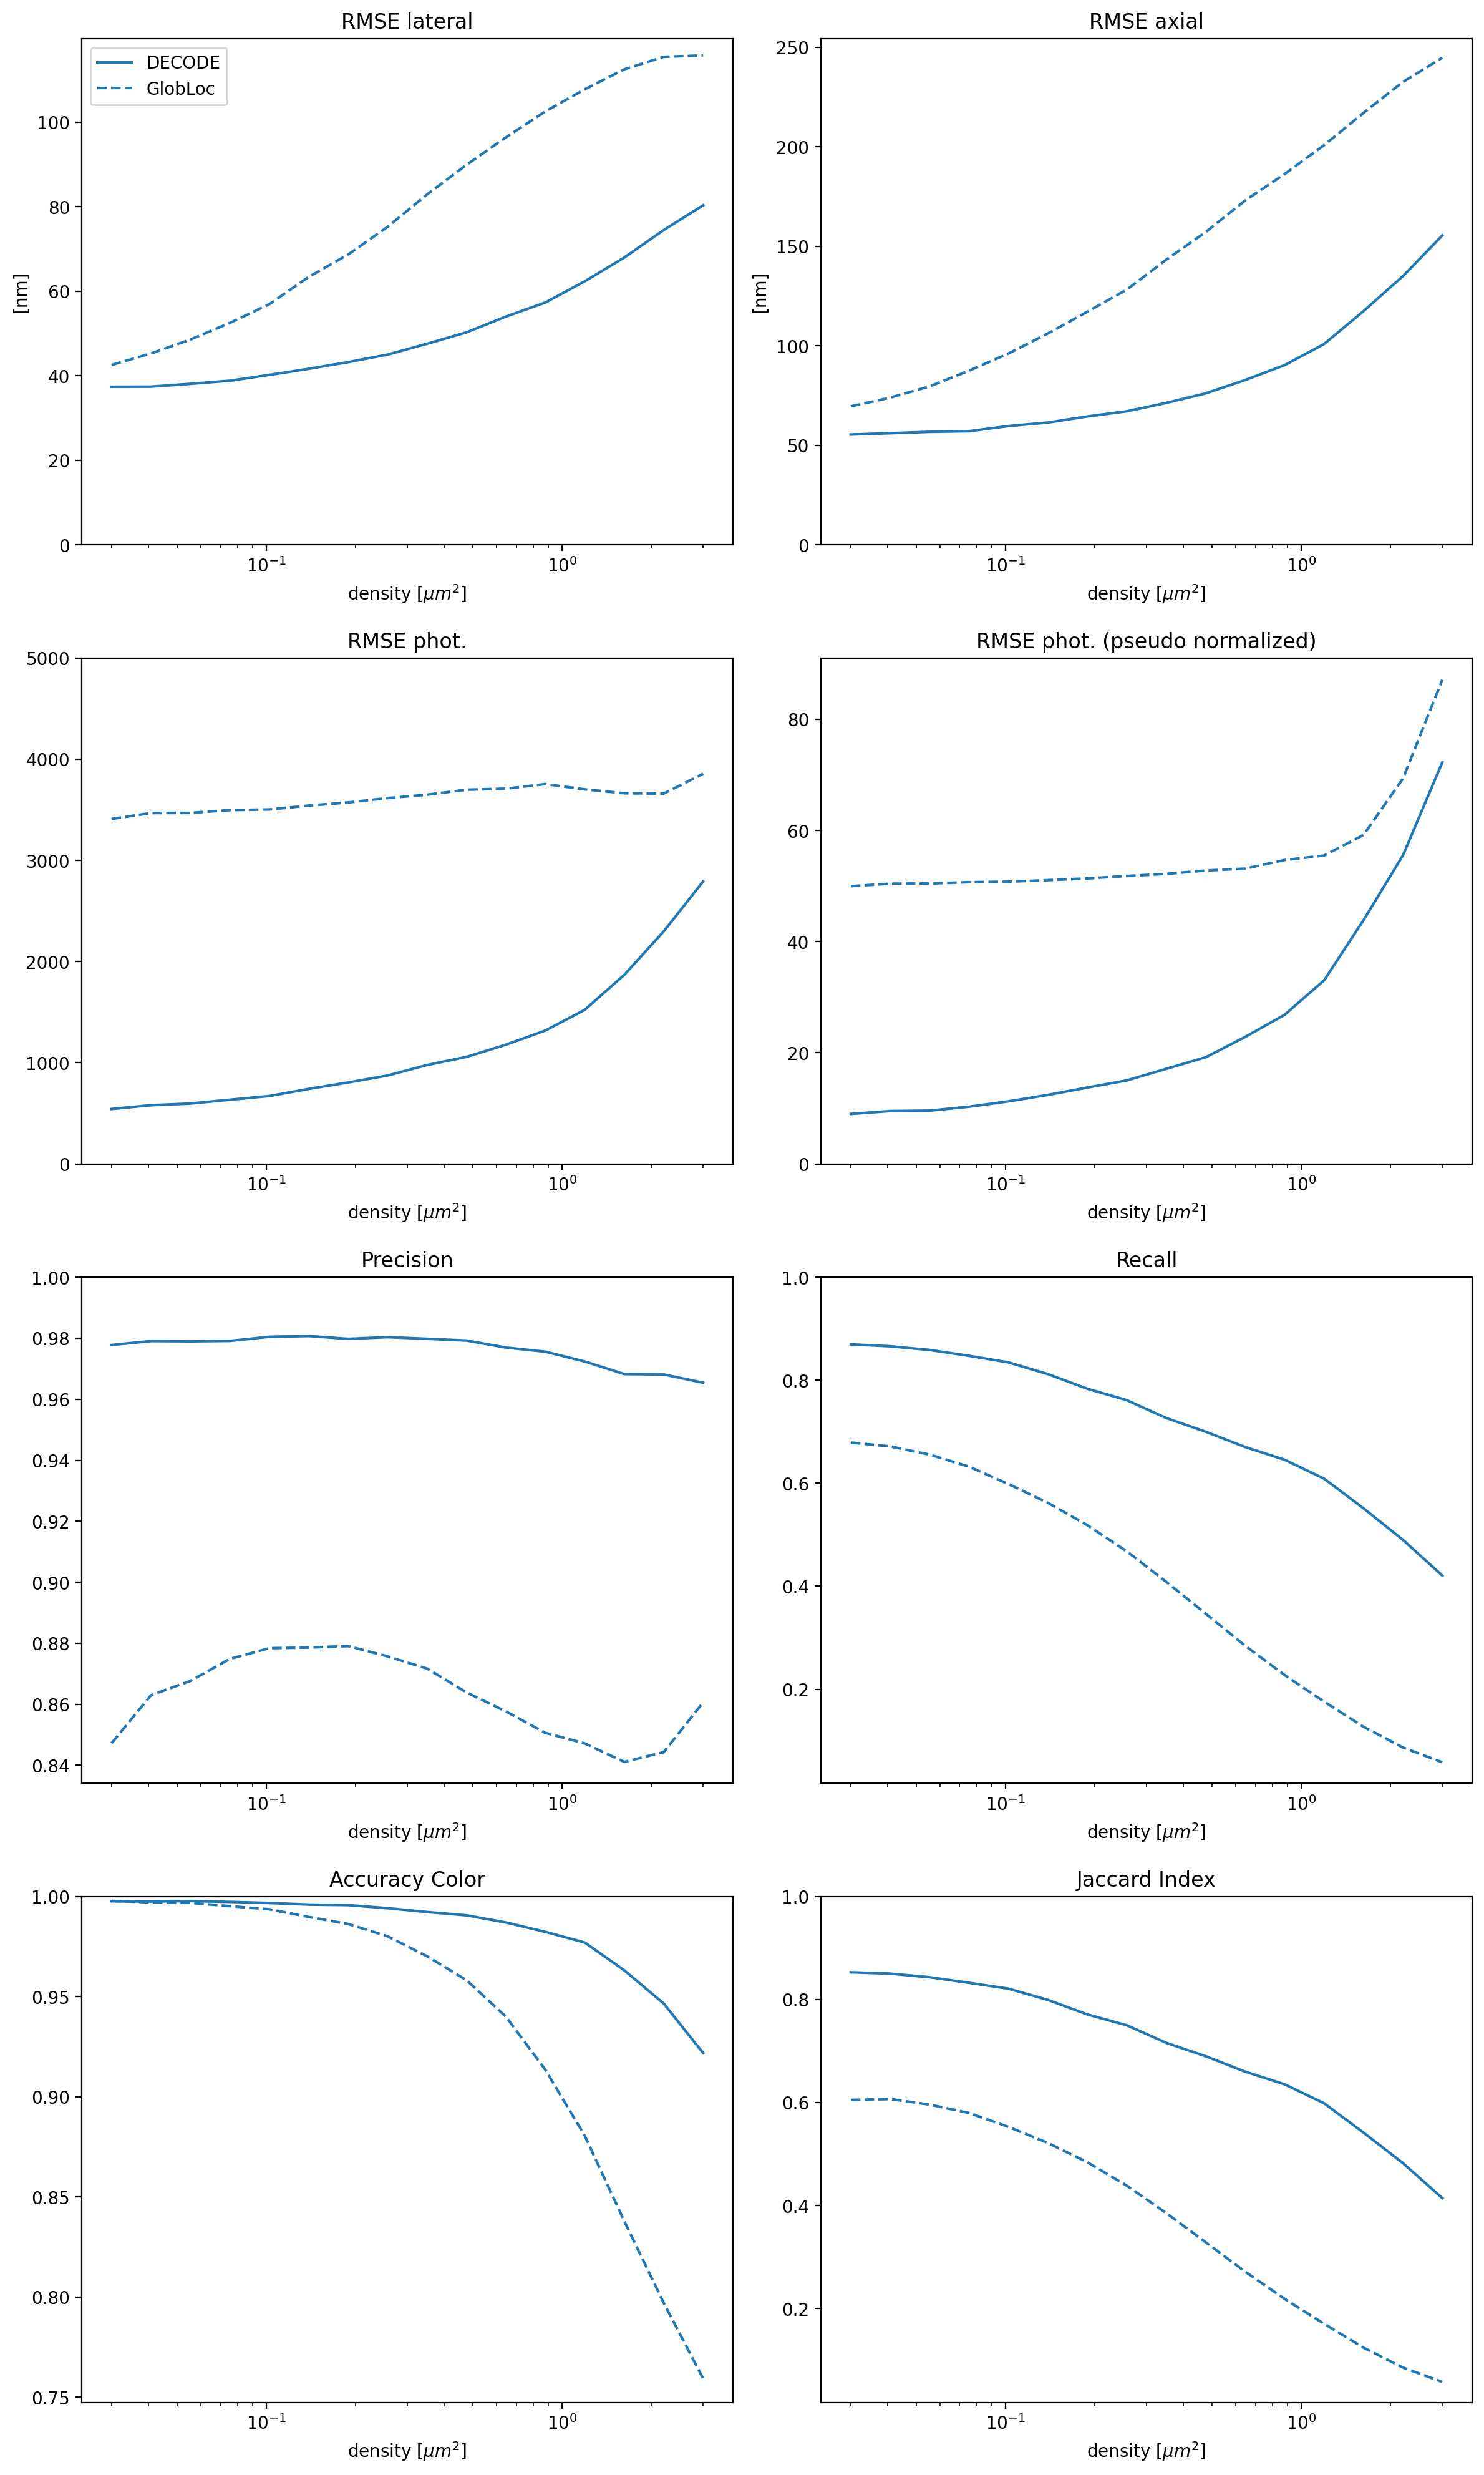

In [16]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
markers = ["-", "--"]

plt_lines = []


metrics = {
    "rmse_lat": {"pretty": "RMSE lateral", "ylabel": "[nm]", "ylim": [0., None], "yscale": "linear"},
    "rmse_ax": {"pretty": "RMSE axial", "ylabel": "[nm]", "ylim": [0., None], "yscale": "linear"},
    "rmse_phot": {"pretty": "RMSE phot.", "ylabel": "", "ylim": [0, 5000], "yscale": "linear"},
    "rmse_phot_pnorm": {"pretty": "RMSE phot. (pseudo normalized)", "ylabel": "", "ylim": [0, None], "yscale": "linear"},
    "prec": {"pretty": "Precision", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    "rec": {"pretty": "Recall", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    "acc_code": {"pretty": "Accuracy Color", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"},
    # "rejection": {"pretty": "Rejection Rate", "ylabel": "", "ylim": [0, None], "yscale": "linear"},
    "jac":{"pretty": "Jaccard Index", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"}
}
m_default = {"pretty": None, "ylim": None, "yscale": "linear"}

for i, (metric, ax) in enumerate(zip(metrics, axs.flat, strict=True)):
    plt_lines = []
    for snr, color in zip(scen_names_pretty, colors):
        for alg, marker in zip(["DECODE", "SMAP"], markers):
            s = evals.join(scen).xs(snr, level="snr").xs(alg, level="algorithm")
            s = s.reset_index().sort_values("n_emitter")

            l, = ax.plot(s.density, s[metric], label=f"{scen_names_pretty[snr]}", color=color, linestyle=marker)
            plt_lines.append(l)


    if i == 0:
        marker_legend = ax.legend(
            [
                Line2D([0], [0], linestyle="-"),#, color="blue"),
                Line2D([0], [0], linestyle="--"),#, color="blue"),
            ],
            ["DECODE", "GlobLoc"],
            loc="best",
        )

        # line_legend = ax.legend(handles=plt_lines[::2], loc="lower left")
        # ax.add_artist(line_legend)

    m_args = m_default.copy()
    m_args |= metrics[metric]

    ax.set_ylim(m_args["ylim"])
    ax.set_xscale("log")
    ax.set_yscale(m_args["yscale"])

    ax.set_title(m_args["pretty"])
    ax.set_xlabel(r"density [$\mu m^2$]")
    ax.set_ylabel(m_args["ylabel"])

plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "metrics.eps",format='eps', dpi=300, bbox_inches="tight")
else:
    plt.show()


[27-04-2026 18:09:42] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


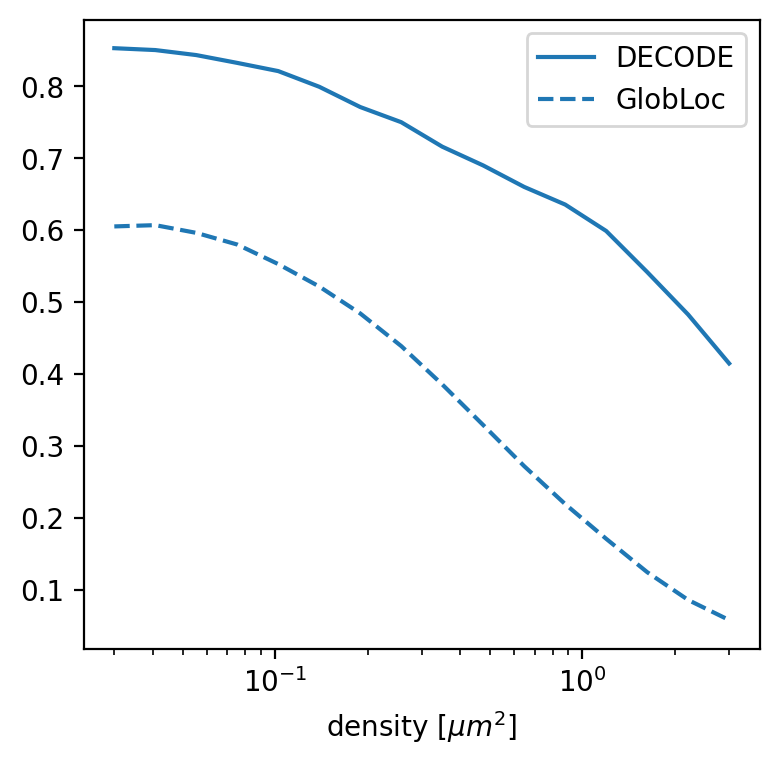

In [17]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
markers = ["-", "--"]

plt_lines = []


metric = {
    "jac":{"pretty": "Jaccard Index", "ylabel": "", "ylim": [None, 1.], "yscale": "linear"}
}
m_default = {"pretty": None, "ylim": None, "yscale": "linear"}


plt_lines = []
for snr, color in zip(scen_names_pretty, colors):
    for alg, marker in zip(["DECODE", "SMAP"], markers):
        s = evals.join(scen).xs(snr, level="snr").xs(alg, level="algorithm")
        s = s.reset_index().sort_values("n_emitter")

        l, = ax.plot(s.density, s["jac"], label=f"{scen_names_pretty[snr]}", color=color, linestyle=marker)
        plt_lines.append(l)

marker_legend = ax.legend(
    [
        Line2D([0], [0], linestyle="-"),#, color="blue"),
        Line2D([0], [0], linestyle="--"),#, color="blue"),
    ],
    ["DECODE", "GlobLoc"],
    loc="best",
)

    # line_legend = ax.legend(handles=plt_lines[::2], loc="lower left")
    # ax.add_artist(line_legend)

m_args = m_default.copy()
m_args |= metric

ax.set_ylim(m_args["ylim"])
ax.set_xscale("log")
ax.set_yscale(m_args["yscale"])

ax.set_title(m_args["pretty"])
ax.set_xlabel(r"density [$\mu m^2$]")
# ax.set_ylabel(m_args["ylabel"])

plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "jac_metrics.eps",format='eps', dpi=300, bbox_inches="tight")
else:
    plt.show()


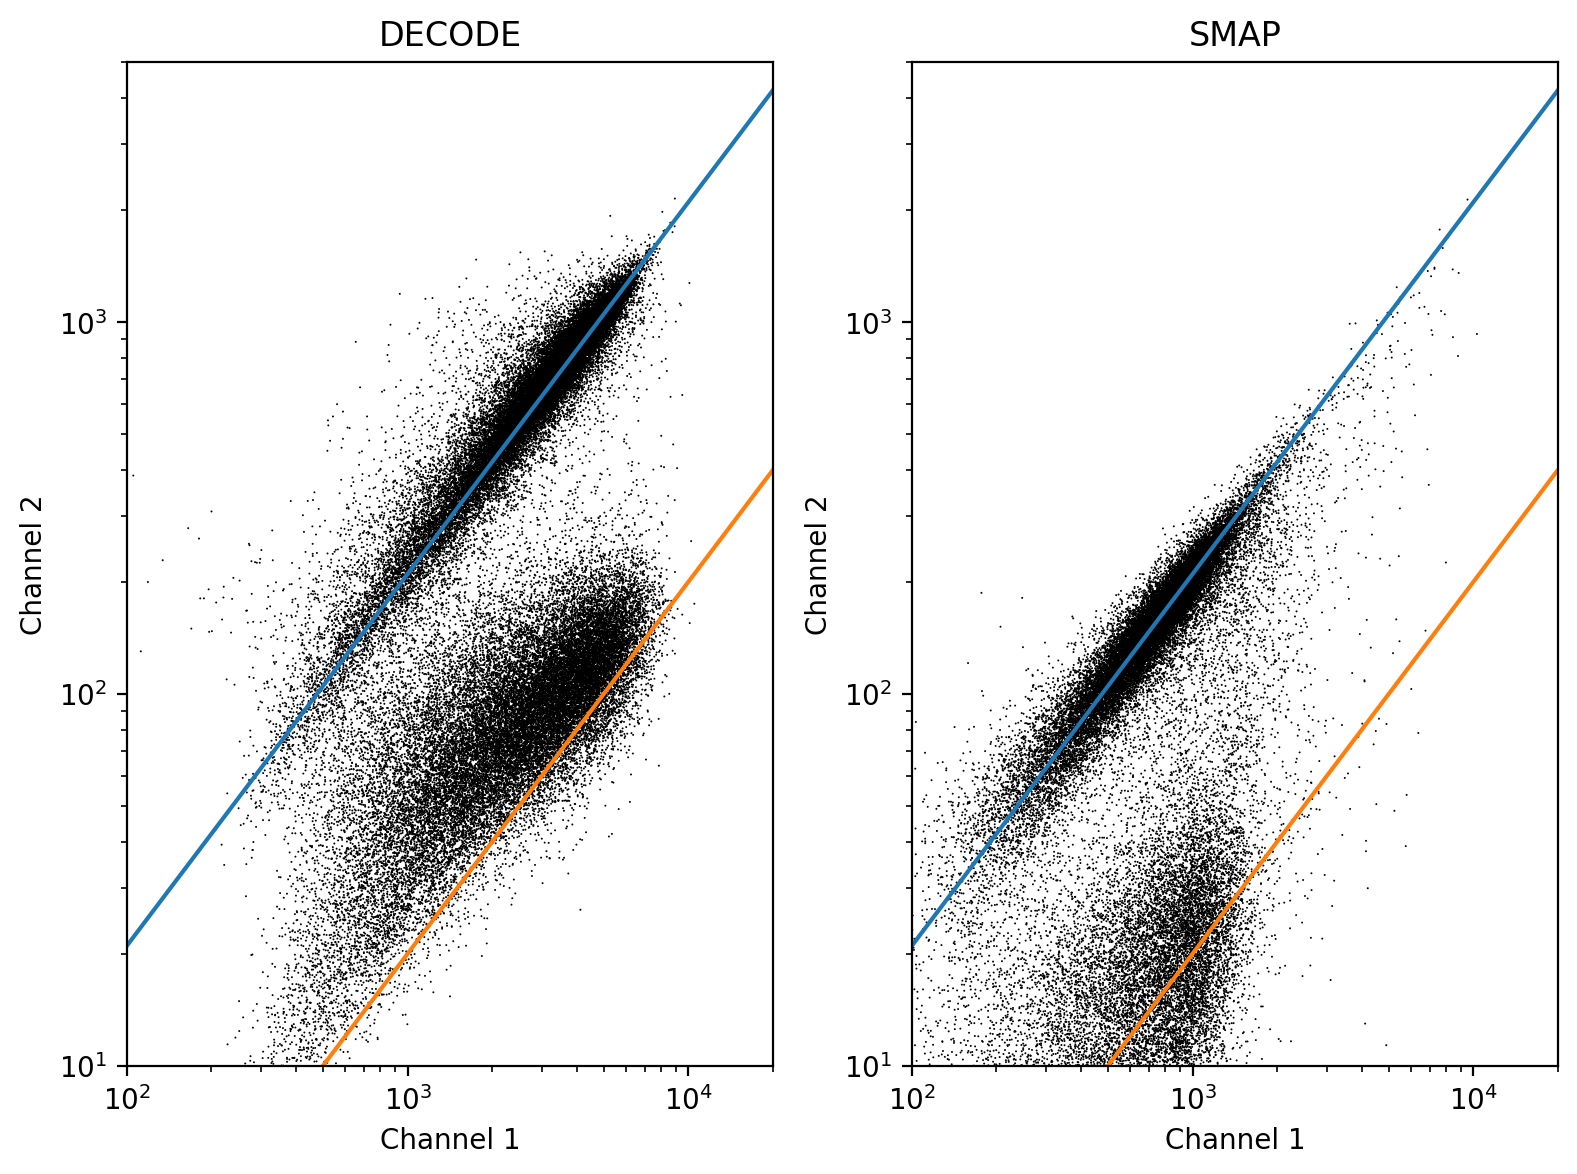

In [18]:
# scatter plots
pred = scen_pred.loc[("medium", 4)]

gt = scen.loc[("medium", 4)]
em_gt = gt.em_ch


fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 6))

for (i, s), ax in zip(pred.iterrows(), axs.flat):
    if s.em_out_fil is None:
        continue

    em = s.em_out_fil
    ax.scatter(em.phot[:, 1], em.phot[:, 0], s=2, color="k", marker=".", facecolors="k", edgecolors="none")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_ylim(1e1, 5e3)
    ax.set_xlim(1e2, 2e4)

    ax.set_xlabel("Channel 1")
    ax.set_ylabel("Channel 2")

    ax.set_title(f"{i}")

    # ratios
    ratios = [0.21, 0.02]
    x = torch.logspace(1, 5, 1000)
    y = [x * rr for rr in ratios]

    for yy in y:
        ax.plot(x, yy, label=str(yy[0].item()))

plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "scatter.eps", format='eps', dpi=300, bbox_inches="tight")
else:
    plt.show()


In [20]:
# sample frames
# df_frames = scen.loc["medium"].iloc[[0, 4]]
df_frames = scen.join(scen_pred[["em_out_fil"]].xs("DECODE", level=2)).iloc[[0, 4]]
f_plot = [frames[i] for i in df_frames.index.get_level_values("index")]

df_frames

n_emitter   density  n_frames          phot_loc  \
snr    index                                                    
medium 0      11.624977  0.030000      1000  [5000.0, 5000.0]   
       4      39.694050  0.102436      1000  [5000.0, 5000.0]   

                    phot_scale             bg          choric    lifetime  \
snr    index                                                                
medium 0      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   
       4      [1250.0, 1250.0]  [20.0, 135.0]  [0.173, 0.019]  [3.0, 1.0]   

              phot_min                                                 em  \
snr    index                                                                
medium 0         100.0  EmitterSet
::num emitters: 21830
::xy unit: px...   
       4         100.0  EmitterSet
::num emitters: 77622
::xy unit: px...   

                                                          em_ch  \
snr    index                                                      
medium 0      EmitterSet
::num emitters: 21830
::xy unit: px...   
       4      EmitterSet
::num emitters: 77622
::xy unit: px...   

                                                     em_out_fil  
snr    index                                                     
medium 0      EmitterSet
::num emitters: 19417
::xy unit: px...  
       4      EmitterSet
::num emitters: 66077
::xy unit: px...

[27-04-2026 18:12:18] [matplotlib.backends.backend_ps] [WARNING] The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


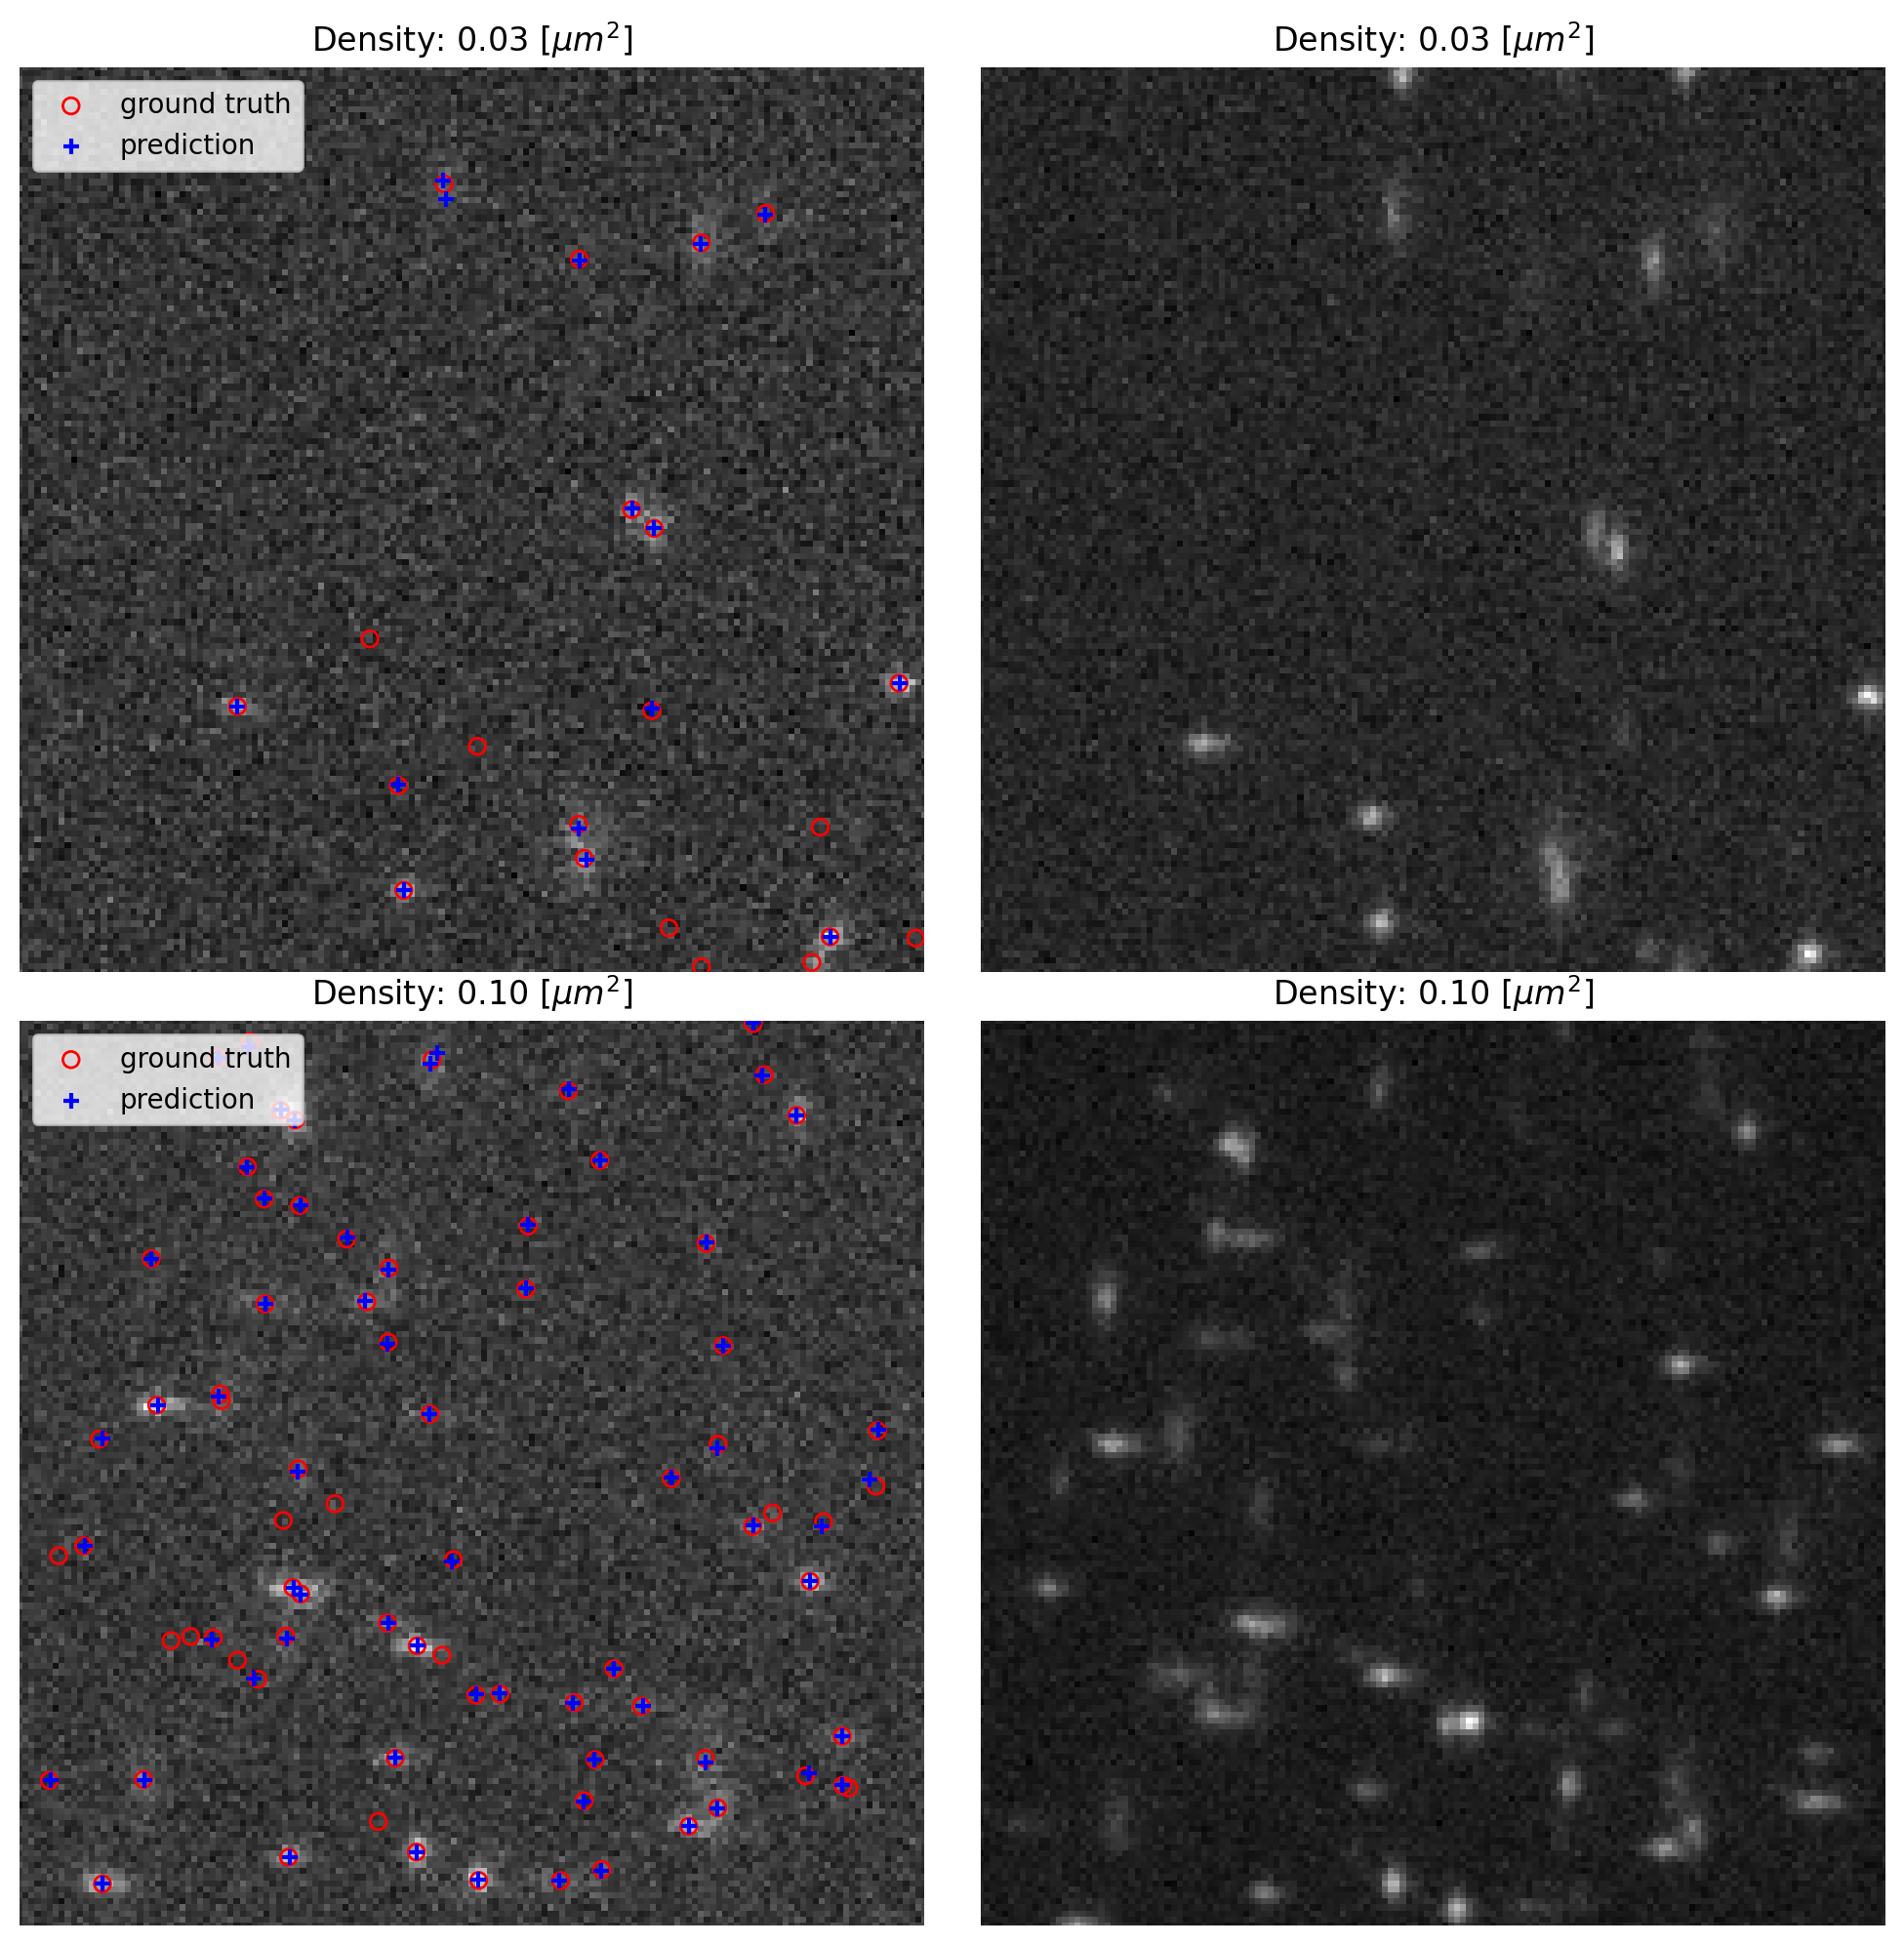

In [21]:
f_ix = 42

xlim = [50, 200]
ylim = xlim

fig, axs = plt.subplots(nrows=len(df_frames), ncols=2, figsize=(10, 10))

for i, ((_, s), f) in enumerate(zip(df_frames.iterrows(), f_plot)):
    em = s.em_ch.iframe[f_ix]
    em_out = s.em_out_fil.iframe[f_ix]

    for j, ff in enumerate(f):
        axs[i, j].imshow(ff[f_ix], cmap="gray")

    axs[i, 0].scatter(em.xyz_px[:, 0, 1], em.xyz_px[:, 0, 0], label="ground truth", marker="o", facecolor="none", edgecolors="r")
    # axs[i, 1].scatter(em.xyz_px[:, 1, 1], em.xyz_px[:, 1, 0], label="channel 2")#, marker="o", facecolor="none", edgecolors="b")

    # decode predictions
    axs[i, 0].scatter(em_out.xyz_px[:, 1], em_out.xyz_px[:, 0], label="prediction", marker="+", facecolor="b", edgecolors="none")
    # axs[i, 1].scatter(em.xyz_px[:, 1, 1], em.xyz_px[:, 1, 0], label="channel 2")#, marker="o", facecolor="none", edgecolors="b")


    for j in range(2):
        ax = axs[i, j]
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_axis_off()
        ax.set_title(f"Density: {s.density:.2f} [$\mu m^2$]")
        if j == 0:
            ax.legend(loc="upper left", frameon=True)

    plt.tight_layout()

if path_out is not None:
    plt.savefig(path_out / "sample_frames.eps", format='eps', dpi=300, bbox_inches="tight")
else:
    plt.show()